In [31]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow kagglehub

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

In [33]:
import kagglehub

path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Path to dataset files: /kaggle/input/sentiment140


In [34]:
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

In [35]:
df = pd.read_csv(full_path, encoding='latin-1', header=None,
                 names=['target', 'ids', 'date', 'flag', 'user', 'text'])

In [36]:
df = df[['text', 'target']].copy()

#0→0 (негатив), 4→1 (позитив)
df['target'] = df['target'].replace(4, 1)

In [37]:
print(f"Загружено примеров: {len(df)}")
print(df['target'].value_counts())

Загружено примеров: 1600000
target
0    800000
1    800000
Name: count, dtype: int64


**Векторизируем всю дату для дальнейшего обучения и проверки**

In [38]:
# Для бинарной классификации берём только позитив (1) и негатив (0)
df_binary = df[df["target"] != 2].copy()

# TF-IDF: тексты → числовые векторы
vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_binary["text"]).toarray()
y = df_binary["target"].values

# Делим на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape[0]} примеров, {X_train.shape[1]} признаков")
print(f"Тестовая выборка:  {X_test.shape[0]} примеров")

Обучающая выборка: 1120000 примеров, 100 признаков
Тестовая выборка:  480000 примеров


**Построение нейросети на keros, обучение на подготовленных данных**
- Количество эпох не имеет значение после 15, можно оставлять так, добавил early stop и количество эпох 50
- добавил ещё слои и регуляризатор

In [39]:
#Создаём модель
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],),
                 kernel_regularizer=regularizers.l2(0.001)),  # L2 регуляризация
    layers.Dropout(0.5),  # Dropout 50% нейронов
    layers.Dense(32, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),  # Dropout 30%
    layers.Dense(1, activation="sigmoid"),
])

#Компиляция
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Early Stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,  # Ждём 5 эпох без улучшений
    restore_best_weights=True
)

#Обучение
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=33,
    validation_split=0.2,
    callbacks=[early_stop])

print("Модель обучена!")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
27152/27152 ━━━━━━━━━━━━━━━━━━━━ 87s 3ms/step - accuracy: 0.6492 - loss: 0.6431 - val_accuracy: 0.6591 - val_loss: 0.6273
Epoch 2/50
27152/27152 ━━━━━━━━━━━━━━━━━━━━ 94s 3ms/step - accuracy: 0.6533 - loss: 0.6342 - val_accuracy: 0.6582 - val_loss: 0.6271
Epoch 3/50
27152/27152 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - accuracy: 0.6541 - loss: 0.6338 - val_accuracy: 0.6610 - val_loss: 0.6266
Epoch 4/50
27152/27152 ━━━━━━━━━━━━━━━━━━━━ 78s 3ms/step - accuracy: 0.6536 - loss: 0.6335 - val_accuracy: 0.6590 - val_loss: 0.6287
Epoch 5/50
27152/27152 ━━━━━━━━━━━━━━━━━━━━ 78s 3ms/step - accuracy: 0.6536 - loss: 0.6338 - val_accuracy: 0.6598 - val_loss: 0.6252
Epoch 6/50
27152/27152 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - accuracy: 0.6539 - loss: 0.6336 - val_accuracy: 0.6600 - val_loss: 0.6267
Epoch 7/50
27152/27152 ━━━━━━━━━━━━━━━━━━━━ 76s 3ms/step - accuracy: 0.6541 - loss: 0.6335 - val_accuracy: 0.6602 - val_loss: 0.6268
Epoch 8/50
27152/27152 ━━━━━━━━━━━━━━━━━━━━ 79s 3ms/step - accuracy: 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,733 (100.52 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,156 (67.02 KB)

Метрики

In [40]:
# Получаем предсказания
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

# Считаем метрики
f1  = f1_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"F1-score:  {f1:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")

F1-score:  0.6606
Precision: 0.6599
Recall:    0.6614


**графики обучения**

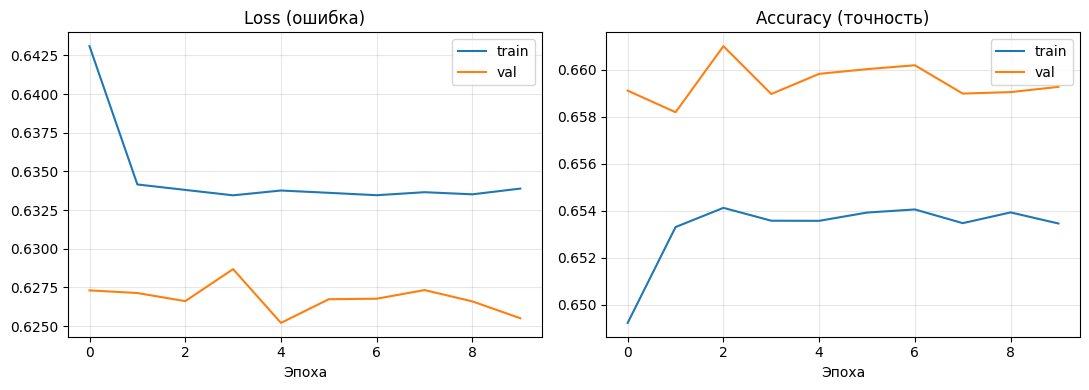

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss (ошибка)")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy (точность)")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()